# 📊 Dashboard Analisis LKE — Evaluasi Reformasi Birokrasi 2024–2025
Notebook ini berisi **Visualisasi LKE** yang akan digunakan untuk penelitian sasaran Reformasi Birokrasi baru, dipresentasikan dengan Conditional & Transparency Coloring

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.patches import FancyBboxPatch
from matplotlib.collections import LineCollection
from matplotlib.ticker import MultipleLocator
import warnings
warnings.filterwarnings('ignore')

# ── Load & Clean ──────────────────────────────────────────────
df = pd.read_csv(r'C:\Users\ASUS\Downloads\Lembar Kerja Evaluasi - Dashboard Hasil Evaluasi (LKE) (1).csv',
                 on_bad_lines='skip', quotechar='"', engine='python')

def clean_num(s):
    try:
        v = str(s).strip()
        return np.nan if v in ['---','','nan'] else float(v)
    except: return np.nan

for col in ['RB General 2024','RB General 2025','RB Tematik 2024',
            'RB Tematik 2025','Index RB 2024','Index RB 2025']:
    df[col] = df[col].apply(clean_num)

df['Delta_Index'] = df['Index RB 2025'] - df['Index RB 2024']
df['Filled_Ratio'] = df['Total Indikator yang Telah Diisi'] / \
                    (df['Total Indikator yang Telah Diisi'] + df['Total Indikator yang Belum Diisi'])

# Predikat ordering
PREDIKAT_ORDER = ['D','C','CC','B','BB','A-','A','AA']
PREDIKAT_COLORS = {
    'D':   '#d62728', 'C':  '#e87b1e', 'CC': '#f4c842',
    'B':   '#98df8a', 'BB': '#2ca02c', 'A-': '#1f77b4',
    'A':   '#17becf', 'AA': '#9467bd'
}

# Global style
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
    'text.color':       'white',
    'grid.color':       '#2e3250',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})

print(f'✅ Data loaded: {len(df)} instansi across {df["Group Instansi"].nunique()} group types')
print(df.groupby('Group Instansi').size())

✅ Data loaded: 653 instansi across 4 group types
Group Instansi
Kabupaten      415
Kementerian    107
Kota            93
Provinsi        38
dtype: int64


---
## Chart 1 — Distribusi Predikat per Group Instansi (Grouped Bar + Transparency)

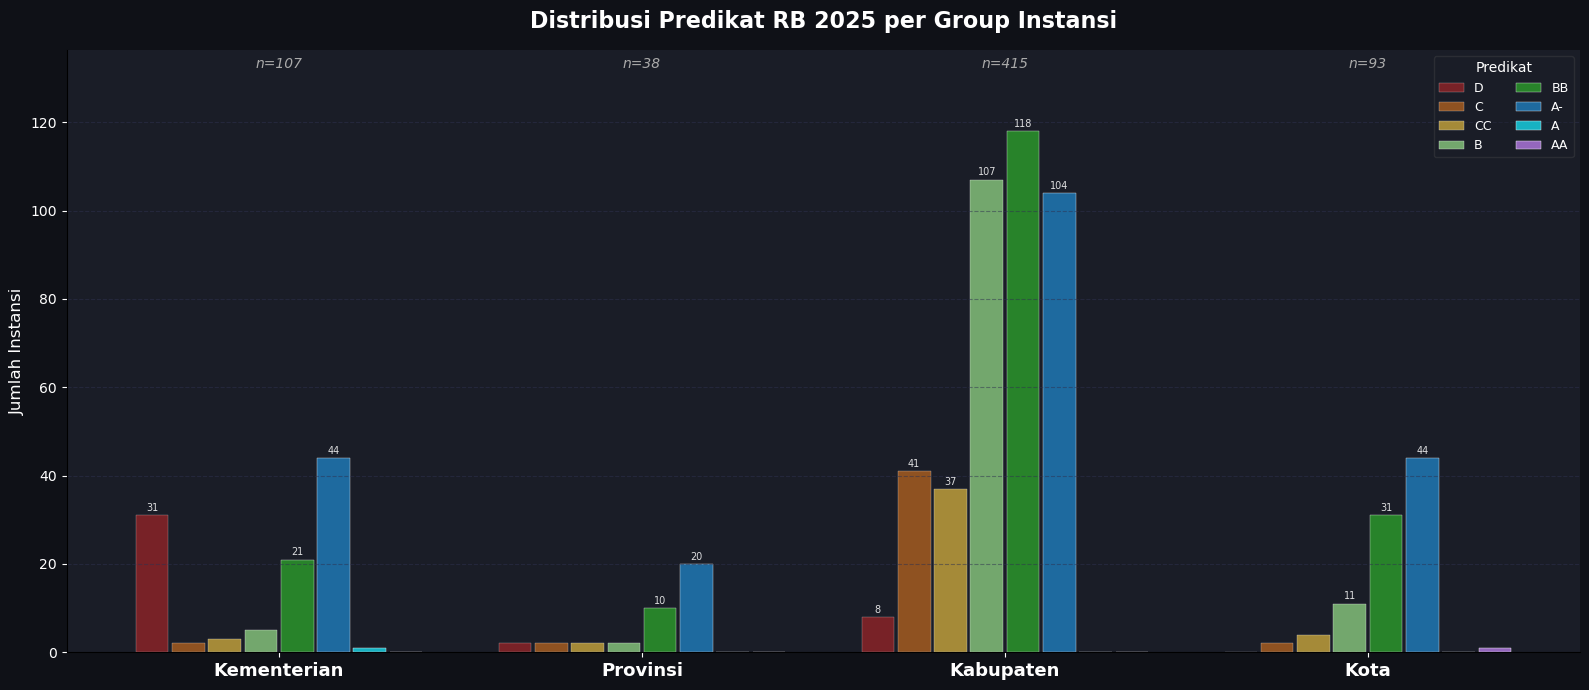

Chart 1 saved.


In [4]:
fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

groups = ['Kementerian','Provinsi','Kabupaten','Kota']
x = np.arange(len(groups))
width = 0.1
alphas = np.linspace(0.5, 1.0, len(PREDIKAT_ORDER))  # Transparency gradient

for i, pred in enumerate(PREDIKAT_ORDER):
    counts = [df[(df['Group Instansi']==g) & (df['Predikat 2025']==pred)].shape[0]
              for g in groups]
    offset = (i - len(PREDIKAT_ORDER)/2 + 0.5) * width
    bars = ax.bar(x + offset, counts, width*0.9,
                  color=PREDIKAT_COLORS[pred],
                  alpha=alphas[i],
                  label=pred,
                  edgecolor='white', linewidth=0.3)
    for bar, cnt in zip(bars, counts):
        if cnt > 5:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    str(cnt), ha='center', va='bottom', fontsize=7,
                    color='white', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=13, fontweight='bold')
ax.set_ylabel('Jumlah Instansi', fontsize=12)
ax.set_title('Distribusi Predikat RB 2025 per Group Instansi',
             fontsize=16, fontweight='bold', pad=16)
ax.legend(title='Predikat', loc='upper right', framealpha=0.3,
          facecolor='#1a1d27', edgecolor='#555', fontsize=9,
          title_fontsize=10, ncol=2)
ax.grid(axis='y')
ax.set_ylim(0, ax.get_ylim()[1] * 1.1)

# Annotate total per group
for xi, g in zip(x, groups):
    total = df[df['Group Instansi']==g].shape[0]
    ax.text(xi, ax.get_ylim()[1]*0.97, f'n={total}',
            ha='center', fontsize=10, color='#aaa', fontstyle='italic')

plt.tight_layout()
plt.savefig('chart1_grouped_bar.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Chart 1 saved.')

---
## Chart 2 — Scatter Plot: RB General vs RB Tematik 2025 (Conditional Color by Index RB)

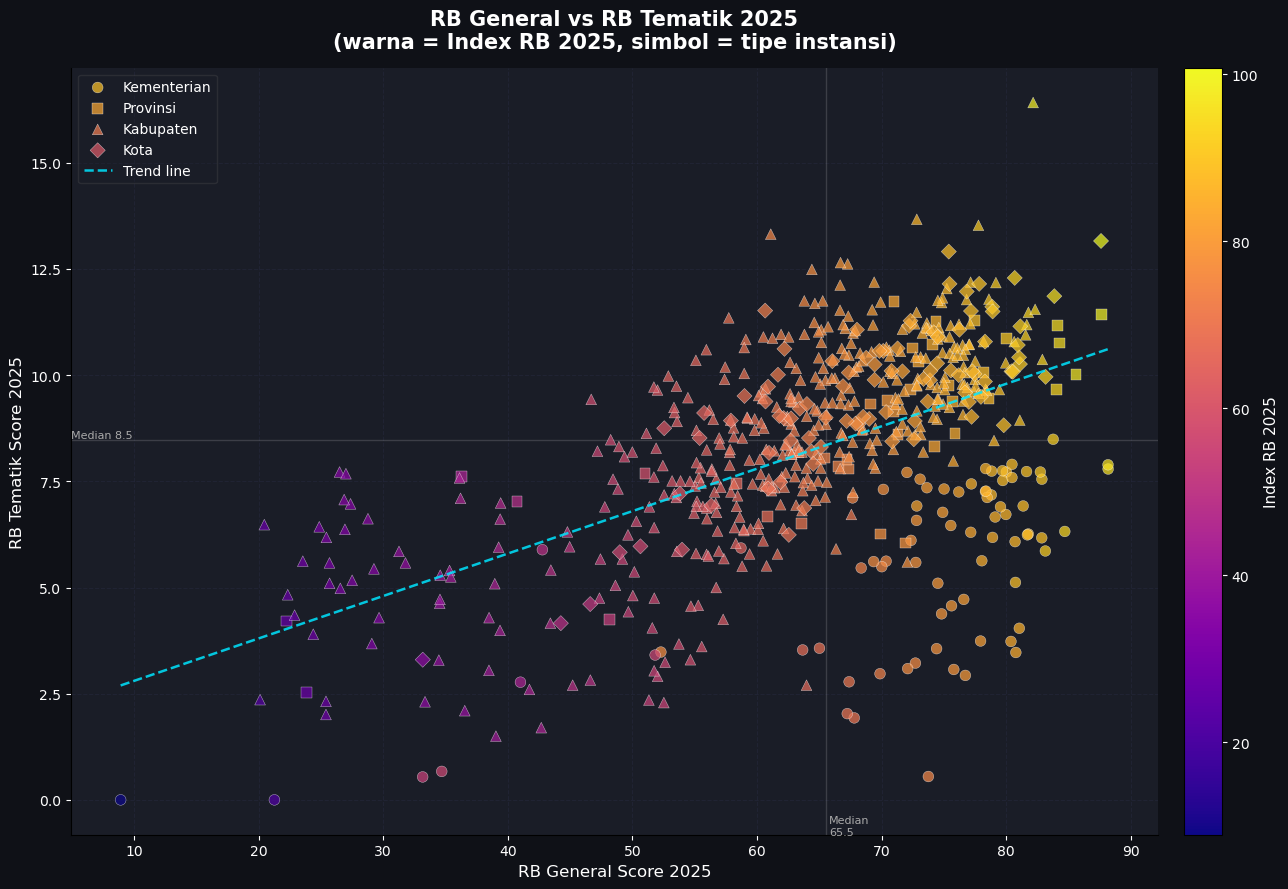

Chart 2 saved.


In [6]:
fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

sub = df.dropna(subset=['RB General 2025','RB Tematik 2025','Index RB 2025'])

# Conditional color by Index RB 2025 value
norm = mcolors.Normalize(vmin=sub['Index RB 2025'].min(), vmax=sub['Index RB 2025'].max())
cmap = cm.get_cmap('plasma')

marker_map = {'Kementerian':'o','Provinsi':'s','Kabupaten':'^','Kota':'D'}

for group, marker in marker_map.items():
    mask = sub['Group Instansi'] == group
    sc = ax.scatter(sub.loc[mask,'RB General 2025'],
                    sub.loc[mask,'RB Tematik 2025'],
                    c=sub.loc[mask,'Index RB 2025'],
                    cmap='plasma', norm=norm,
                    s=60, alpha=0.72, marker=marker,
                    edgecolors='white', linewidths=0.3,
                    label=group, zorder=3)

# Colorbar
cbar = plt.colorbar(cm.ScalarMappable(norm=norm, cmap='plasma'), ax=ax, pad=0.02)
cbar.set_label('Index RB 2025', fontsize=11)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

# Regression line
from numpy.polynomial.polynomial import polyfit
x_vals = sub['RB General 2025'].values
y_vals = sub['RB Tematik 2025'].values
c0, c1 = polyfit(x_vals, y_vals, 1)
x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
ax.plot(x_line, c0 + c1*x_line, '--', color='#00e5ff', linewidth=1.8,
        alpha=0.85, label='Trend line', zorder=4)

# Quadrant lines at medians
med_x, med_y = np.median(x_vals), np.median(y_vals)
ax.axvline(med_x, color='#ffffff', alpha=0.15, linewidth=1)
ax.axhline(med_y, color='#ffffff', alpha=0.15, linewidth=1)
ax.text(med_x + 0.3, ax.get_ylim()[0]*1.01, f'Median\n{med_x:.1f}',
        color='#aaa', fontsize=8)
ax.text(ax.get_xlim()[0]*1.002, med_y + 0.05, f'Median {med_y:.1f}',
        color='#aaa', fontsize=8)

ax.set_xlabel('RB General Score 2025', fontsize=12)
ax.set_ylabel('RB Tematik Score 2025', fontsize=12)
ax.set_title('RB General vs RB Tematik 2025\n(warna = Index RB 2025, simbol = tipe instansi)',
             fontsize=15, fontweight='bold', pad=14)
ax.legend(loc='upper left', framealpha=0.3, facecolor='#1a1d27',
          edgecolor='#555', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('chart2_scatter.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Chart 2 saved.')

---
## Chart 3 — Diverging Bar: Delta Index RB (2024→2025), Top & Bottom 30 Instansi

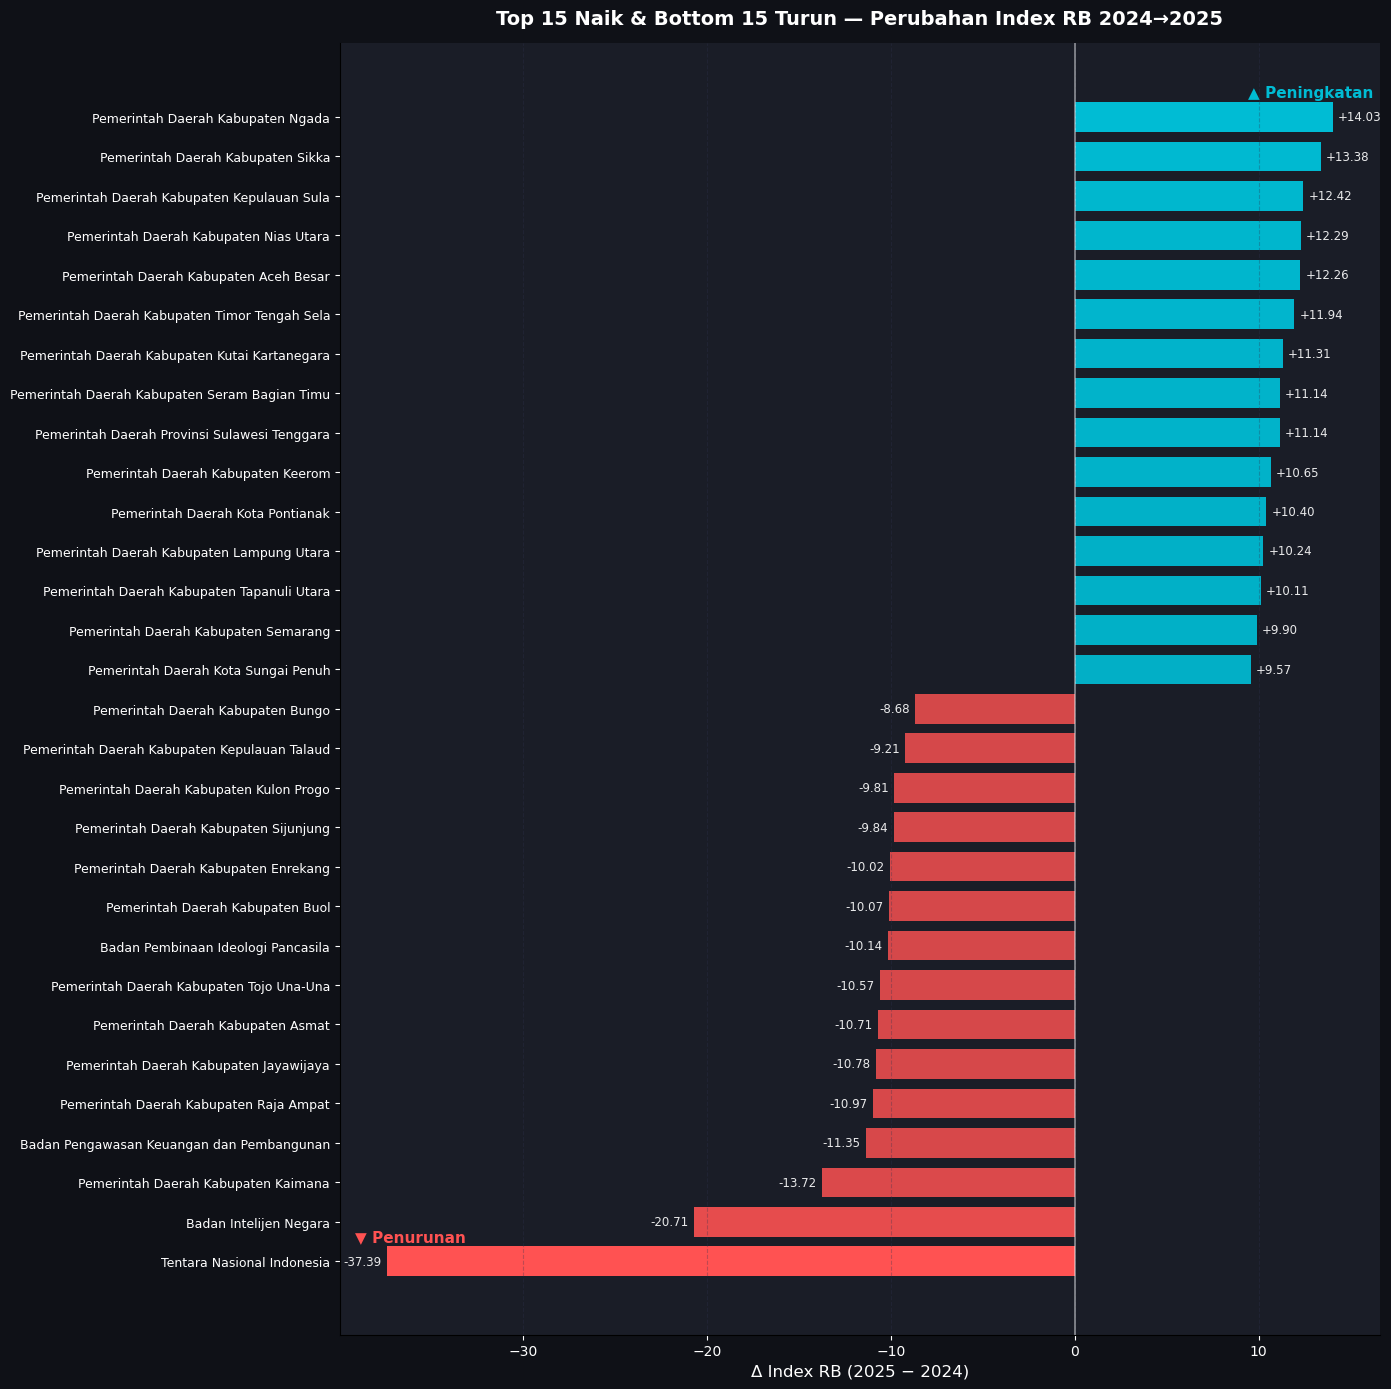

Chart 3 saved.


In [8]:
fig, ax = plt.subplots(figsize=(14, 14))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

delta_df = df.dropna(subset=['Delta_Index']).copy()
top15  = delta_df.nlargest(15, 'Delta_Index')
bot15  = delta_df.nsmallest(15, 'Delta_Index')
plot_df = pd.concat([top15, bot15]).sort_values('Delta_Index', ascending=True)

labels = plot_df['Instansi Pemerintah'].str[:45].values
values = plot_df['Delta_Index'].values

# Conditional color: positive = teal gradient, negative = red gradient
def delta_color(v, alpha_base=0.6):
    if v >= 0:
        intensity = min(1.0, 0.4 + v / values.max() * 0.6)
        return (*mcolors.to_rgb('#00bcd4'), min(1.0, alpha_base + intensity * 0.4))
    else:
        intensity = min(1.0, 0.4 + abs(v) / abs(values.min()) * 0.6)
        return (*mcolors.to_rgb('#ff5252'), min(1.0, alpha_base + intensity * 0.4))

colors = [delta_color(v) for v in values]
y = np.arange(len(labels))

bars = ax.barh(y, values, color=colors, edgecolor='none', height=0.75)

# Value labels
for bar, val in zip(bars, values):
    x_pos = bar.get_width() + (0.3 if val >= 0 else -0.3)
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{val:+.2f}', va='center', ha=ha, fontsize=8.5, color='white', alpha=0.9)

ax.axvline(0, color='white', linewidth=1.2, alpha=0.5)
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Δ Index RB (2025 − 2024)', fontsize=12)
ax.set_title('Top 15 Naik & Bottom 15 Turun — Perubahan Index RB 2024→2025',
             fontsize=14, fontweight='bold', pad=14)

# Annotations
ax.text(ax.get_xlim()[1]*0.98, len(labels)-0.5, '▲ Peningkatan',
        ha='right', color='#00bcd4', fontsize=11, fontweight='bold')
ax.text(ax.get_xlim()[0]*0.98, 0.5, '▼ Penurunan',
        ha='left', color='#ff5252', fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('chart3_diverging.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Chart 3 saved.')

---
## Chart 4 — Heatmap: Rata-rata Index RB 2025 per Predikat × Group Instansi

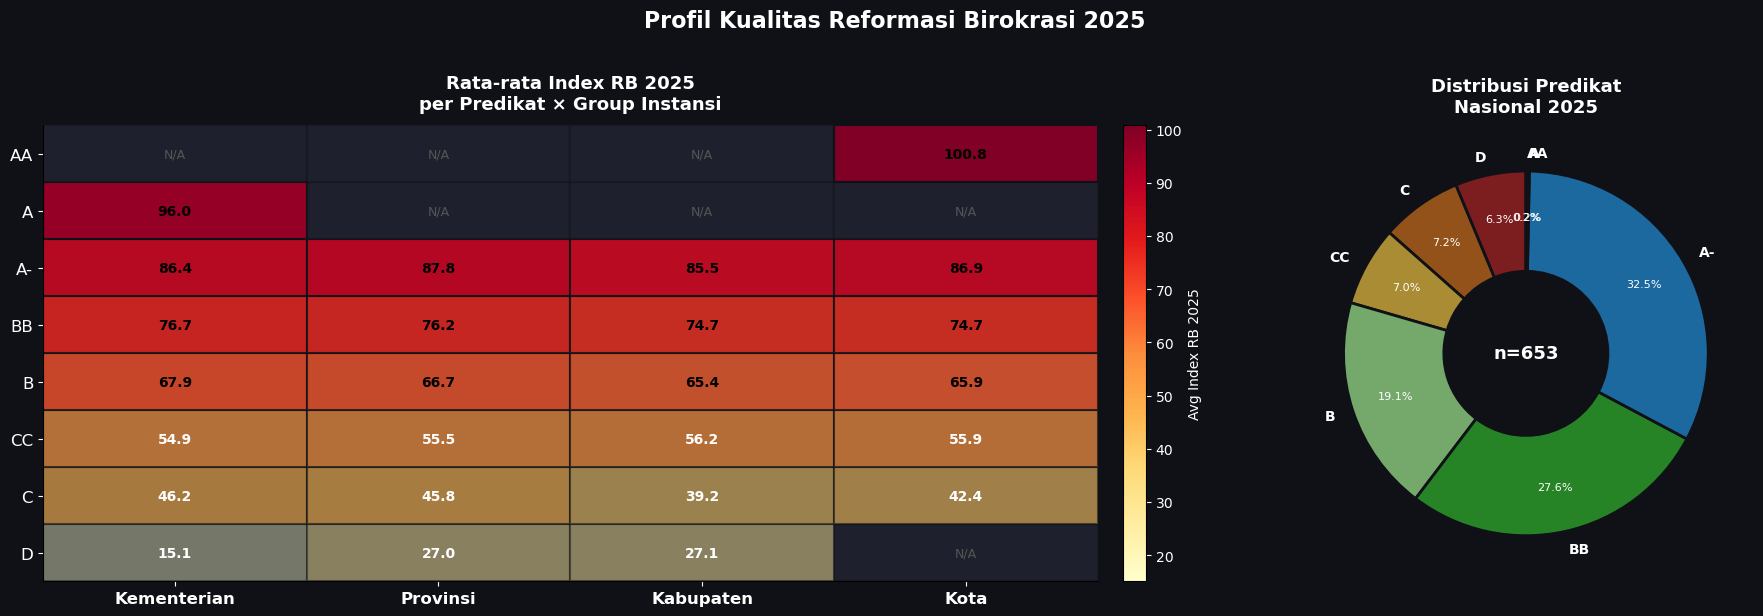

Chart 4 saved.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [2.5, 1]})
fig.patch.set_facecolor('#0f1117')

# --- Left: Heatmap ---
ax = axes[0]
ax.set_facecolor('#1a1d27')

groups = ['Kementerian','Provinsi','Kabupaten','Kota']
pivot = df.groupby(['Predikat 2025','Group Instansi'])['Index RB 2025'].mean().unstack(fill_value=np.nan)
pivot = pivot.reindex(index=PREDIKAT_ORDER, columns=groups)

data_arr = pivot.values
cmap_heat = cm.get_cmap('YlOrRd')
norm_heat = mcolors.Normalize(vmin=np.nanmin(data_arr), vmax=np.nanmax(data_arr))

for i in range(data_arr.shape[0]):
    for j in range(data_arr.shape[1]):
        val = data_arr[i, j]
        alpha = 0.3 if np.isnan(val) else 0.4 + 0.6 * norm_heat(val)  # Transparency coloring
        color = '#2a2d3e' if np.isnan(val) else cmap_heat(norm_heat(val))
        rect = plt.Rectangle([j-0.5, i-0.5], 1, 1,
                              facecolor=color, alpha=alpha, edgecolor='#0f1117', linewidth=1.5)
        ax.add_patch(rect)
        if not np.isnan(val):
            ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                    fontsize=10, fontweight='bold',
                    color='black' if norm_heat(val) > 0.55 else 'white')
        else:
            ax.text(j, i, 'N/A', ha='center', va='center', fontsize=9, color='#555')

ax.set_xlim(-0.5, len(groups)-0.5)
ax.set_ylim(-0.5, len(PREDIKAT_ORDER)-0.5)
ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups, fontsize=12, fontweight='bold')
ax.set_yticks(range(len(PREDIKAT_ORDER)))
ax.set_yticklabels(PREDIKAT_ORDER, fontsize=12)
ax.set_title('Rata-rata Index RB 2025\nper Predikat × Group Instansi',
             fontsize=13, fontweight='bold', pad=12)
cbar2 = plt.colorbar(cm.ScalarMappable(norm=norm_heat, cmap='YlOrRd'), ax=ax, pad=0.02)
cbar2.set_label('Avg Index RB 2025', fontsize=10)
plt.setp(cbar2.ax.yaxis.get_ticklabels(), color='white')

# --- Right: Predikat Distribution Donut ---
ax2 = axes[1]
ax2.set_facecolor('#1a1d27')
pred_counts = df['Predikat 2025'].value_counts().reindex(PREDIKAT_ORDER, fill_value=0)
wedge_colors = [PREDIKAT_COLORS[p] for p in pred_counts.index]
wedge_alphas = np.linspace(0.55, 1.0, len(pred_counts))
rgba_colors = [(r,g,b,a) for (r,g,b), a in
               zip([mcolors.to_rgb(c) for c in wedge_colors], wedge_alphas)]

wedges, texts, autotexts = ax2.pie(
    pred_counts.values, labels=pred_counts.index,
    colors=rgba_colors, autopct='%1.1f%%',
    pctdistance=0.75, startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='#0f1117', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(8); at.set_color('white')
for t in texts:
    t.set_fontsize(10); t.set_color('white'); t.set_fontweight('bold')
ax2.set_title('Distribusi Predikat\nNasional 2025', fontsize=13, fontweight='bold', pad=10)
ax2.text(0, 0, f"n={len(df)}", ha='center', va='center', fontsize=13,
         color='white', fontweight='bold')

fig.suptitle('Profil Kualitas Reformasi Birokrasi 2025', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart4_heatmap_donut.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Chart 4 saved.')

---
## Chart 5 — Violin Plot: Distribusi Index RB 2025 per Group Instansi (Conditional + Transparency)

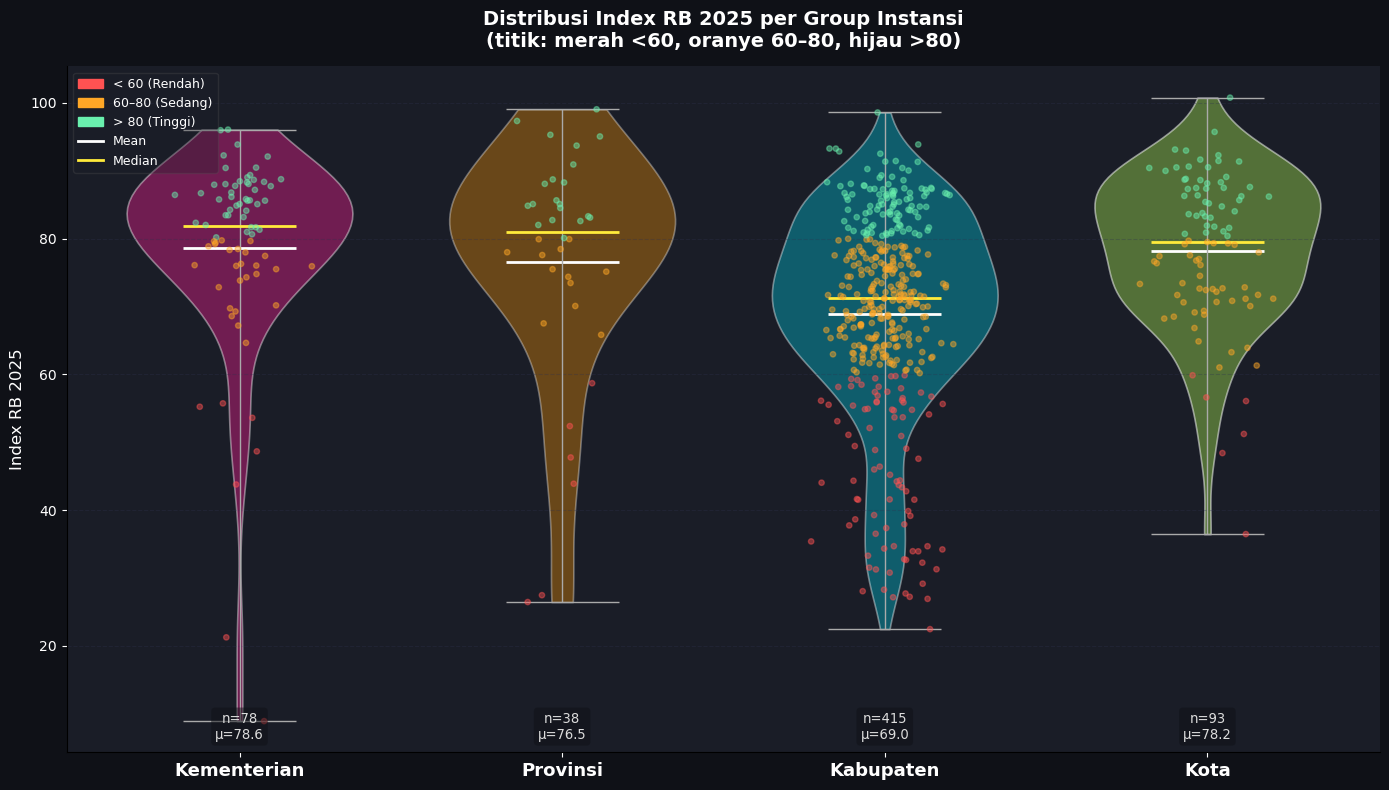

Chart 5 saved.


In [12]:
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

groups = ['Kementerian','Provinsi','Kabupaten','Kota']
group_colors  = ['#e91e8c','#ff9800','#00bcd4','#8bc34a']
group_data = [df[df['Group Instansi']==g]['Index RB 2025'].dropna().values for g in groups]

parts = ax.violinplot(group_data, positions=range(len(groups)),
                      showmeans=True, showmedians=True, widths=0.7)

# Style each violin with conditional transparency
for i, (pc, color) in enumerate(zip(parts['bodies'], group_colors)):
    pc.set_facecolor(color)
    pc.set_edgecolor('white')
    pc.set_linewidth(1.2)
    # Transparency based on variance
    alpha_val = 0.35 + 0.45 * (1 - np.std(group_data[i]) / max(np.std(d) for d in group_data))
    pc.set_alpha(alpha_val)

parts['cmeans'].set_color('#ffffff')
parts['cmeans'].set_linewidth(2)
parts['cmedians'].set_color('#ffeb3b')
parts['cmedians'].set_linewidth(2)

for key in ['cbars','cmins','cmaxes']:
    parts[key].set_color('#aaaaaa')
    parts[key].set_linewidth(1)

# Overlay strip jitter
for i, (data, color) in enumerate(zip(group_data, group_colors)):
    jitter = np.random.normal(0, 0.08, size=len(data))
    # Conditional coloring: points below 60 = red, 60-80 = orange, >80 = green
    point_colors = ['#ff5252' if v < 60 else '#ffa726' if v < 80 else '#69f0ae' for v in data]
    ax.scatter(i + jitter, data, c=point_colors, s=15, alpha=0.45, zorder=3)

# Annotations: mean + n
for i, (data, g) in enumerate(zip(group_data, groups)):
    ax.text(i, ax.get_ylim()[0] + 2, f'n={len(data)}\nμ={np.mean(data):.1f}',
            ha='center', fontsize=9.5, color='#ddd',
            bbox=dict(facecolor='#0f1117', alpha=0.5, boxstyle='round,pad=0.3', edgecolor='none'))

ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups, fontsize=13, fontweight='bold')
ax.set_ylabel('Index RB 2025', fontsize=12)
ax.set_title('Distribusi Index RB 2025 per Group Instansi\n'
             '(titik: merah <60, oranye 60–80, hijau >80)',
             fontsize=14, fontweight='bold', pad=14)

# Legend
legend_elements = [
    mpatches.Patch(color='#ff5252', label='< 60 (Rendah)'),
    mpatches.Patch(color='#ffa726', label='60–80 (Sedang)'),
    mpatches.Patch(color='#69f0ae', label='> 80 (Tinggi)'),
    plt.Line2D([0],[0], color='white', linewidth=2, label='Mean'),
    plt.Line2D([0],[0], color='#ffeb3b', linewidth=2, label='Median'),
]
ax.legend(handles=legend_elements, loc='upper left', framealpha=0.3,
          facecolor='#1a1d27', edgecolor='#555', fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('chart5_violin.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Chart 5 saved.')

---
## Chart 6 — Bubble Chart: Provinsi — Filled Ratio vs Avg Index RB (ukuran = jumlah instansi)

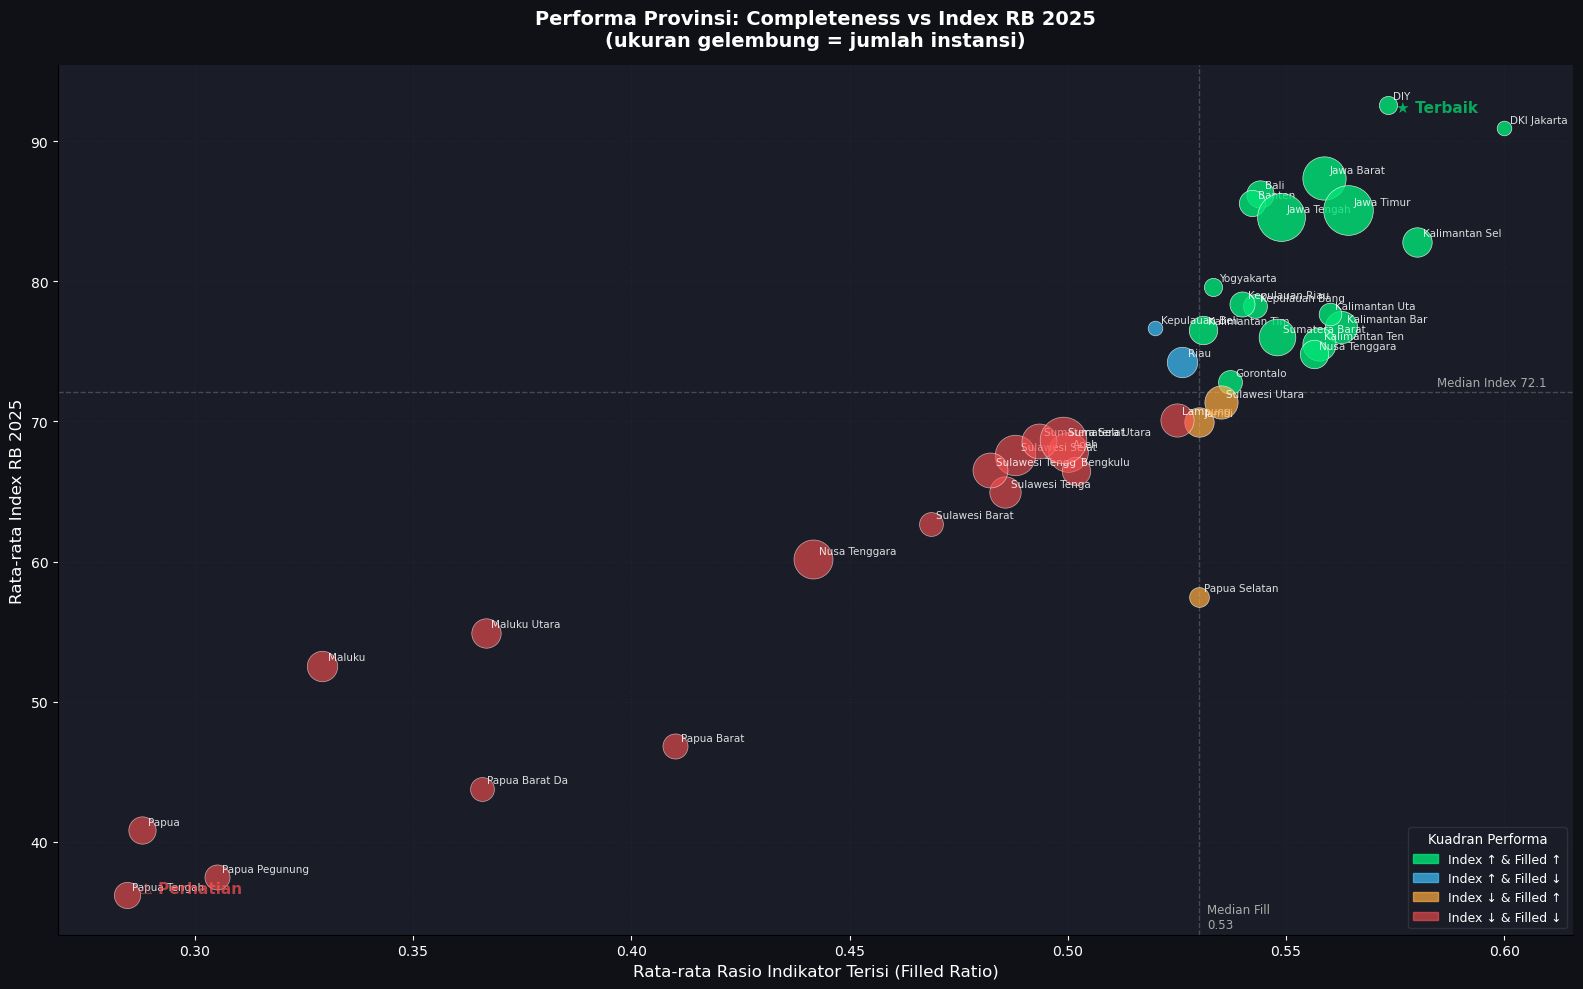

Chart 6 saved.


In [14]:
fig, ax = plt.subplots(figsize=(16, 10))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

prov_df = df[df['Provinsi'].notna() & (df['Provinsi'] != '')]
prov_agg = prov_df.groupby('Provinsi').agg(
    avg_index = ('Index RB 2025','mean'),
    avg_filled = ('Filled_Ratio','mean'),
    count = ('Instansi Pemerintah','count')
).dropna().reset_index()

# Conditional colors: classify by performance quadrant
med_idx    = prov_agg['avg_index'].median()
med_filled = prov_agg['avg_filled'].median()

def quad_color(row):
    hi = row['avg_index'] >= med_idx
    filled = row['avg_filled'] >= med_filled
    if hi and filled:   return ('#00e676', 0.80)  # High perf, well filled
    elif hi:            return ('#40c4ff', 0.70)  # High perf, less filled
    elif filled:        return ('#ffab40', 0.70)  # Lower perf, well filled
    else:               return ('#ff5252', 0.60)  # Lower perf, less filled

colors_alpha = prov_agg.apply(quad_color, axis=1)
colors_list  = [c[0] for c in colors_alpha]
alphas_list  = [c[1] for c in colors_alpha]

sizes = (prov_agg['count'] / prov_agg['count'].max() * 1200 + 80)

for _, row in prov_agg.iterrows():
    idx_pos = prov_agg.index[prov_agg['Provinsi']==row['Provinsi']][0]
    c, a = colors_list[idx_pos], alphas_list[idx_pos]
    ax.scatter(row['avg_filled'], row['avg_index'],
               s=sizes[idx_pos], color=c, alpha=a,
               edgecolors='white', linewidths=0.5, zorder=3)
    ax.annotate(row['Provinsi'][:14],
                xy=(row['avg_filled'], row['avg_index']),
                xytext=(4, 4), textcoords='offset points',
                fontsize=7.5, color='white', alpha=0.85)

# Quadrant lines
ax.axvline(med_filled, color='white', alpha=0.2, linewidth=1, linestyle='--')
ax.axhline(med_idx,    color='white', alpha=0.2, linewidth=1, linestyle='--')
ax.text(ax.get_xlim()[1]*0.99, med_idx + 0.4, f'Median Index {med_idx:.1f}',
        ha='right', color='#aaa', fontsize=8.5)
ax.text(med_filled + 0.002, ax.get_ylim()[0]+0.5, f'Median Fill\n{med_filled:.2f}',
        color='#aaa', fontsize=8.5)

# Quadrant labels
ax.text(prov_agg['avg_filled'].max()*0.99, prov_agg['avg_index'].max()*0.995,
        '★ Terbaik', ha='right', color='#00e676', fontsize=11, fontweight='bold', alpha=0.7)
ax.text(prov_agg['avg_filled'].min()*1.01, prov_agg['avg_index'].min()*1.005,
        '⚠ Perhatian', ha='left', color='#ff5252', fontsize=11, fontweight='bold', alpha=0.7)

# Legend for quadrant colors
legend_q = [
    mpatches.Patch(color='#00e676', alpha=0.8, label='Index ↑ & Filled ↑'),
    mpatches.Patch(color='#40c4ff', alpha=0.7, label='Index ↑ & Filled ↓'),
    mpatches.Patch(color='#ffab40', alpha=0.7, label='Index ↓ & Filled ↑'),
    mpatches.Patch(color='#ff5252', alpha=0.6, label='Index ↓ & Filled ↓'),
]
ax.legend(handles=legend_q, loc='lower right', framealpha=0.35,
          facecolor='#1a1d27', edgecolor='#555', fontsize=9,
          title='Kuadran Performa', title_fontsize=9.5)

ax.set_xlabel('Rata-rata Rasio Indikator Terisi (Filled Ratio)', fontsize=12)
ax.set_ylabel('Rata-rata Index RB 2025', fontsize=12)
ax.set_title('Performa Provinsi: Completeness vs Index RB 2025\n(ukuran gelembung = jumlah instansi)',
             fontsize=14, fontweight='bold', pad=14)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('chart6_bubble.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Chart 6 saved.')

---
## Chart 7 — Slope Chart: Perubahan Predikat 2024→2025 (Naik / Tetap / Turun)

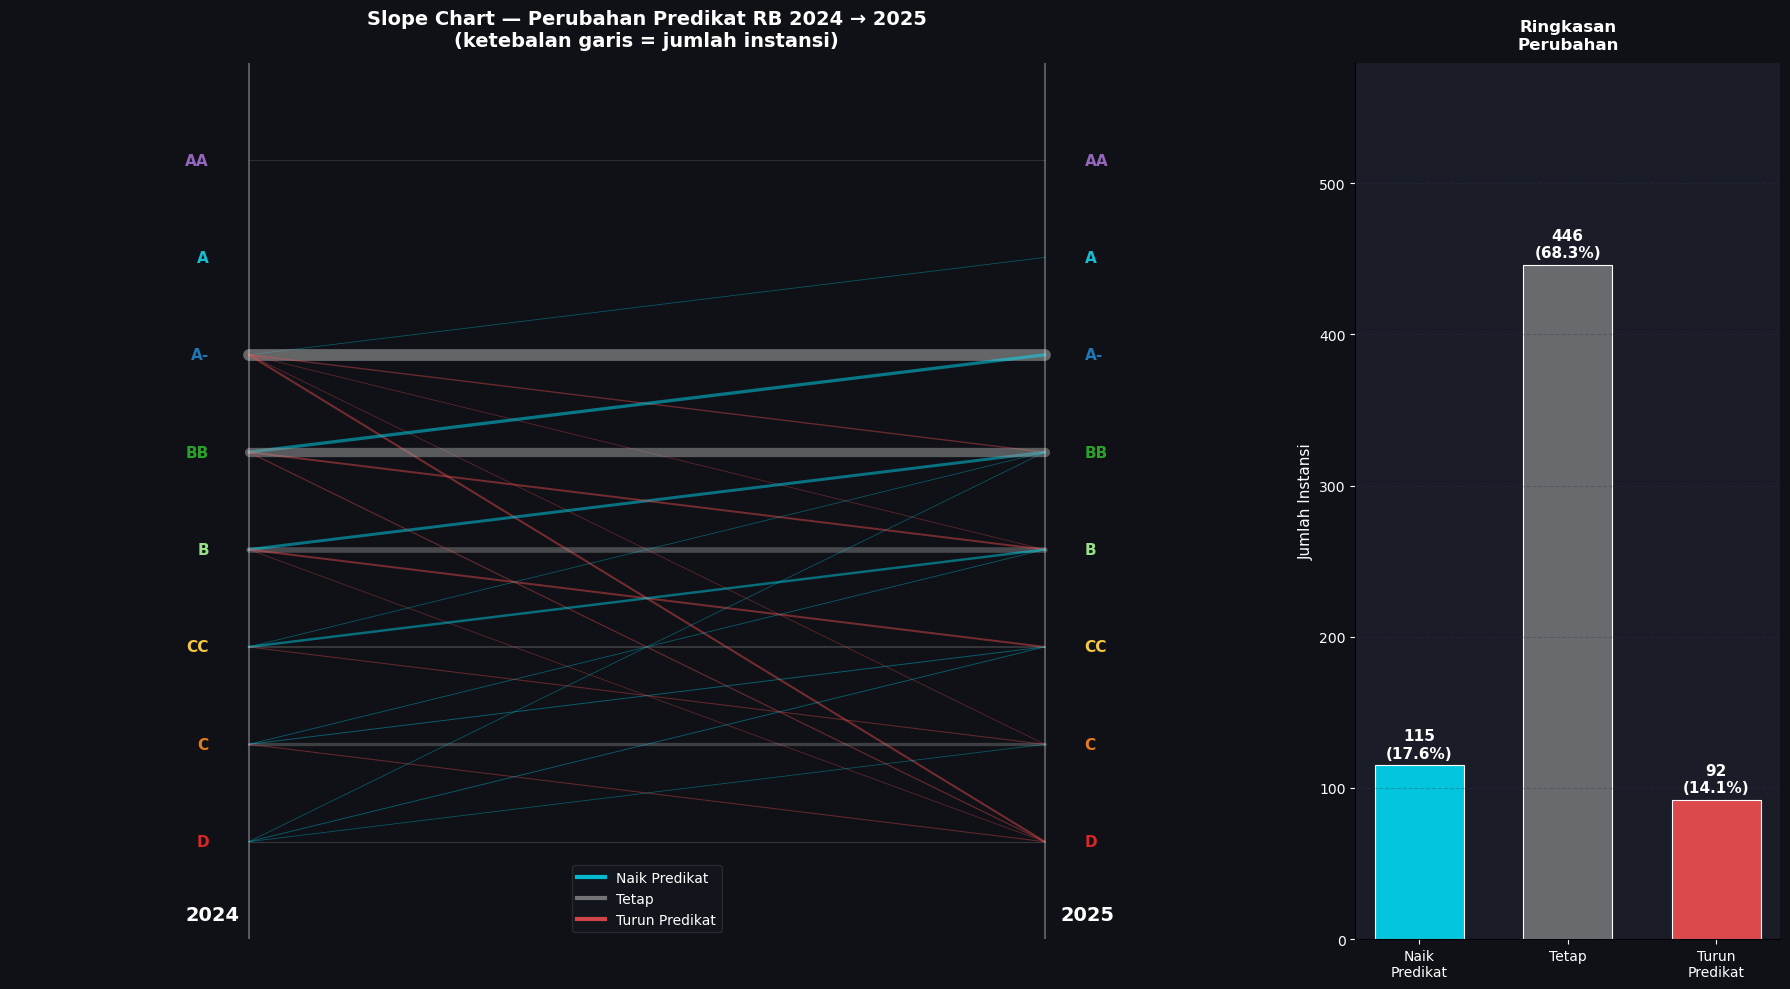

Chart 7 saved.

✅ Semua 7 chart berhasil dibuat!


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10), gridspec_kw={'width_ratios': [3, 1]})
fig.patch.set_facecolor('#0f1117')

ax = axes[0]
ax.set_facecolor('#1a1d27')

pred_map = {p: i for i, p in enumerate(PREDIKAT_ORDER)}
slope_df = df[df['Predikat 2024'].isin(PREDIKAT_ORDER) & df['Predikat 2025'].isin(PREDIKAT_ORDER)].copy()
slope_df['rank_2024'] = slope_df['Predikat 2024'].map(pred_map)
slope_df['rank_2025'] = slope_df['Predikat 2025'].map(pred_map)
slope_df['change'] = slope_df['rank_2025'] - slope_df['rank_2024']

# Count transitions for line thickness
trans_count = slope_df.groupby(['Predikat 2024','Predikat 2025']).size().reset_index(name='n')
max_n = trans_count['n'].max()

for _, row in trans_count.iterrows():
    y1 = pred_map[row['Predikat 2024']]
    y2 = pred_map[row['Predikat 2025']]
    lw = 0.5 + (row['n'] / max_n) * 8
    change = y2 - y1
    # Conditional color: up=teal, same=grey, down=red
    if change > 0:
        color, alpha = '#00e5ff', 0.35 + 0.55 * (row['n'] / max_n)
    elif change == 0:
        color, alpha = '#9e9e9e', 0.25 + 0.35 * (row['n'] / max_n)
    else:
        color, alpha = '#ff5252', 0.35 + 0.55 * (row['n'] / max_n)
    ax.plot([0, 1], [y1, y2], color=color, lw=lw, alpha=alpha, solid_capstyle='round')

# Labels on both sides
for i, pred in enumerate(PREDIKAT_ORDER):
    ax.text(-0.05, i, pred, ha='right', va='center', fontsize=11, fontweight='bold',
            color=PREDIKAT_COLORS[pred])
    ax.text(1.05,  i, pred, ha='left',  va='center', fontsize=11, fontweight='bold',
            color=PREDIKAT_COLORS[pred])

ax.axvline(0, color='white', alpha=0.3, linewidth=1.5)
ax.axvline(1, color='white', alpha=0.3, linewidth=1.5)
ax.text(-0.08, -0.8, '2024', fontsize=14, fontweight='bold', color='white')
ax.text(1.02, -0.8, '2025', fontsize=14, fontweight='bold', color='white')
ax.set_xlim(-0.3, 1.3)
ax.set_ylim(-1, len(PREDIKAT_ORDER))
ax.axis('off')
ax.set_title('Slope Chart — Perubahan Predikat RB 2024 → 2025\n'
             '(ketebalan garis = jumlah instansi)',
             fontsize=14, fontweight='bold', pad=12)

legend_slope = [
    plt.Line2D([0],[0], color='#00e5ff', lw=3, alpha=0.8, label='Naik Predikat'),
    plt.Line2D([0],[0], color='#9e9e9e', lw=3, alpha=0.7, label='Tetap'),
    plt.Line2D([0],[0], color='#ff5252', lw=3, alpha=0.8, label='Turun Predikat'),
]
ax.legend(handles=legend_slope, loc='lower center', framealpha=0.35,
          facecolor='#1a1d27', edgecolor='#555', fontsize=10)

# --- Right panel: summary counts ---
ax2 = axes[1]
ax2.set_facecolor('#1a1d27')

naik  = (slope_df['change'] > 0).sum()
tetap = (slope_df['change'] == 0).sum()
turun = (slope_df['change'] < 0).sum()
total = naik + tetap + turun

categories = ['Naik\nPredikat', 'Tetap', 'Turun\nPredikat']
counts_s   = [naik, tetap, turun]
bar_colors = ['#00e5ff', '#9e9e9e', '#ff5252']
bar_alphas = [0.85, 0.60, 0.85]

bars2 = ax2.bar(categories, counts_s,
                color=[(*mcolors.to_rgb(c), a) for c, a in zip(bar_colors, bar_alphas)],
                edgecolor='white', linewidth=0.8, width=0.6)

for bar, cnt in zip(bars2, counts_s):
    pct = cnt / total * 100
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 3,
             f'{cnt}\n({pct:.1f}%)', ha='center', va='bottom',
             fontsize=11, fontweight='bold', color='white')

ax2.set_ylabel('Jumlah Instansi', fontsize=11)
ax2.set_title('Ringkasan\nPerubahan', fontsize=12, fontweight='bold', pad=10)
ax2.set_ylim(0, max(counts_s) * 1.3)
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('chart7_slope.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Chart 7 saved.')
print(f'\n✅ Semua 7 chart berhasil dibuat!')